# Extension to a multi-dimensional and time dependent Problem

In [1]:
import os
# Surpress unnecessary output from tensorflow package
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# Change the working dorectory, for easier imports and running
os.chdir(os.path.dirname(os.path.abspath('../pyproject.toml')))

# Import necessary functions/ packages
from Utils.plot import int_3D_plot, plot_animated, simp_plot, plot_err_vs_epoch, plot_twoD_error
from PINNLearning.data import gen_data, set_boundaries, time_sim, gen_rand_2D_data, set_2D_boundaries, twoD_sim
from PINNLearning.training import learning_rate_schedule, time_loss, twoD_loss, train
from PINNLearning.models import create_model
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import keras

As before, we are setting some initial settings primarily for plotting.

In [2]:
# Plot settings
plt.close('all')
plt.rcParams['font.family'] = 'Ubuntu Nerd Font'
plt.rcParams['font.size'] = 10

# Dimensions of the simulation space
lower_bound = 0.0
upper_bound = 1.0

## Introduction to time dependence

We continue our exploration of the heat equation written below, but this time we will consider it as time-dependent.

$\dfrac{\partial u(x, t)}{\partial t} = \alpha \cdot \Delta u(x, t)$

To accommodate this change, the initial simplifications need to be adjusted as follows:
- The diffusion factor is set to a constant value: $\alpha = 0.1$
- The function remains one-dimensional, so we have: $\Delta u(x, t) = \frac{\partial^2 u(x, t)}{\partial^2x}$


In this context, the diffusion factor $\alpha$ is reduced to extend the "time" it takes for heat to spread throughout the system. This adjustment aids the PINN in converging, as neural networks often struggle with complex, erratic functions. This issue was also observed in the previous section of the notebook `1D & time-independent` problems. Furthermore this leads to nicer looking results.

The problem remains normalized over the range $[0,1]$, and this normalization extends to the time domain.
The Dirichlet boundary conditions are specified across the entire time range similar to before:

$u(0) = 1$ and $u(1) = 0$

Additionally, we need to introduce an initial condition for $u(x,0)$, which is defined as:

$u(x,0) = 0.5 \cdot cos(2 \cdot \pi \cdot x) + 0.5$ 

It is not strictly required for the initial solution to satisfy the boundary conditions outlined above. However, if the initial solution does not meet these conditions, both the simulated and PINN solutions may exhibit some error in relation to the problem's definition.

Due to the complexity of finding an analytical solution, a simulated approach needs to be employed again.
In this simulation, time is discretized into small intervals, and the solution is computed at each time step. This necessitates an important stability condition, which establishes a relationship between the step sizes (denoted as $\Delta$) in the $x$ and $t$ domains.
This condition is known as the Courant-Friedrichs-Lewy (CFL) condition, which states:

$r = \alpha \cdot \dfrac{\Delta t}{\Delta x^2} \overset{!}{\leq} \dfrac{1}{2}$

With the fixed discretization of the spatial domain and the specified value for $\alpha$, the CFL condition serves as the foundation for calculating the discretization of the time domain. However, since all domains are normalized, this will not impact the visual outcome of the simulation.

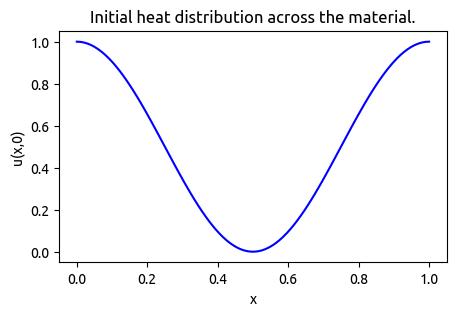

In [3]:
# Create the data for the simulation and set the initial solution

# Discretize the x dimension
x_train = gen_data(lower_bound, upper_bound, 100)

# Set the boundary conditions
x_bc, y_bc = set_boundaries([[0.0], [1.0]], [[1.0], [0.0]])

# Create a function to generate the initial solution for t=0
def init_sol(array):
    # set the initial function with respect
    # to the boundary conditions
    return 0.5 * np.cos(2 * np.pi * array) + 0.5

# Set an examplery initial solution 
init_vals = init_sol(x_train)

# View the initial solution
plt = simp_plot([x_train, init_vals, 'b'],
                'Initial heat distribution across the material.',
                ylabel='u(x,0)'
                )
plt.show()

In [4]:
# Simulate the PDE
final_res, hist, times = time_sim(x_train, y_bc, init_sol, 5)


Converged at time t=3.11478s in 30528 steps.


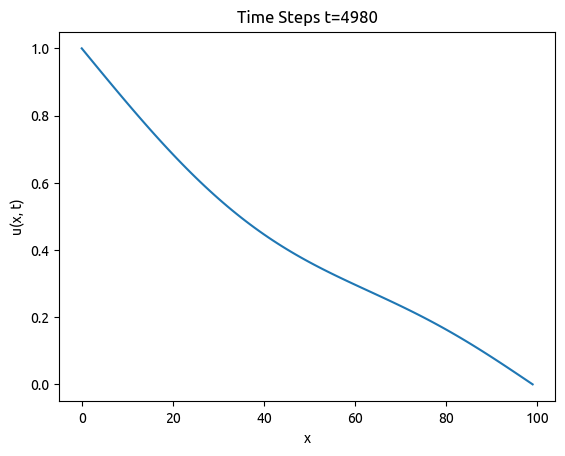

In [5]:
# Plot an animation of the initial development over time
# FYI: This plot is limited in the displayed time frame
# and does not show full convergence!
plot_animated(hist[:5000:20], pause=0.0001, iterator=20)


In [6]:
# Create a 3D plot of the simulation

# Limit the number of displayed time steps, for easier plotting
hist = hist[::20]

m = len(hist)      # number of time steps
n = len(hist[0])   # number of x samples

# Set up the axis
x = np.linspace(lower_bound, upper_bound, n)  # spatial dimension
z = np.linspace(lower_bound, upper_bound, m)  # temporal dimension - normalized to be in [0, 1]
X, Z = np.meshgrid(x, z)
Y = np.array(hist)  # results

plt = int_3D_plot(X, Z, Y, "Plot of the simulated spatio-temporal solution", ylabel='t', zlabel='z(x, t)')
plt.show()

In this scenario, the following setup of the PINN differs significantly from that of the simulation.
This problem must be treated here as a two-dimensional problem in both space and time. Consequently, the training and validation data must be sampled from the $x-t~plane$, and the boundary conditions themselves must be represented as vectors of constant samples across the time domain.

With this added complexity, it is evident that the model must also increase in complexity. To accommodate this, the neural network now includes more hidden layers. Additionally, the training budget needs to be expanded; the training duration will be longer, and the learning rate must initially be increased before being gradually reduced according to the schedule. Other modifications to the framework focus primarily on adjusting the residual to be minimized and incorporating the initial solution as an additional loss term.

In this implementation, it is unlikely that the model will converge to a final solution; instead, it exhausts the training budget.
Training performance could be enhanced by further increasing the budget, the number of data points and batching the training data. Batching can be activated by providing the `train()` function with a specified batch size.
Against typicall practices, for PINNs much larger batch sizes (a typicall size would otherwise be 32) are recommended ([source](https://www.semanticscholar.org/paper/On-the-impact-of-larger-batch-size-in-the-training-Sankaran-Wang/6a89167f1764acf26e8f34871d71e65ab7a47263)).

Batching is a technique used to improve the efficiency and performance of training algorithms. Instead of processing the entire dataset at once, the data is divided into smaller subsets called batches. Each batch contains a certain power of two of randomly selected data points from the original dataset.
During training, the model is updated individually for each batch. In addition to the obvious benefits of reducing memory requirements, this approach leads to a "noisy" gradient, which can enhance exploration, and results in a higher update frequency. This may lead to faster convergence.
However, a downside is that as the number of batches increases, the gradients of the model need to be computed more frequently. This differentiation is the most time-intensive step of the learning process and can become a limiting factor in the use of this technique if sufficient parallelization is not possible.


See for more information: [Medium.com](https://medium.com/analytics-vidhya/when-and-why-are-batches-used-in-machine-learning-acda4eb00763)

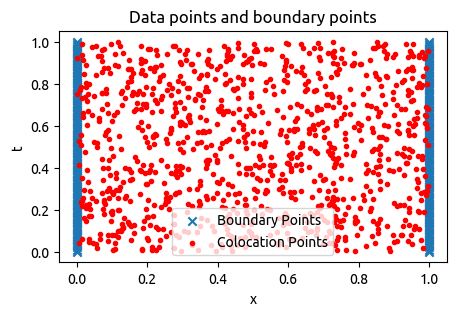

In [7]:
# Create the training and validation data set for the PINN

# Sample 1000 (x, t) pairs for training
xt_train = gen_rand_2D_data(lower_bound, upper_bound, 1000)

# Generate 900 (x, t) pairs for verification
x_samps = gen_data(lower_bound, upper_bound, 30)
t_samps = gen_data(lower_bound, upper_bound, 30)
grid = tf.meshgrid(x_samps, t_samps)
grid = tf.stack(grid, axis=-1)
xt_test = tf.reshape(grid, [-1, 2])


# Extend the given boudary values to fit the 2D approach
# FYI: As the boundary conditions are set as u(<x_bound>, t), they must be provided
# as a vector of values, sampled throught the time domain. For the t_sample points,
# we are using here the x_train vector just for simplicity.
xt_bc, yt_bc = set_2D_boundaries(x_bc, y_bc, x_train)


# Plot the data points
data = [
    [xt_bc[:, 0], xt_bc[:, 1], ('marker', 'x'), 'scatter', ('label', 'Boundary Points')],
    [xt_train[:, 0], xt_train[:, 1], ('marker', '.'), ('c', 'r'), 'scatter', ('label', 'Colocation Points')]
    ]
plt = simp_plot(data, "Data points and boundary points", ylabel="t")
plt.show()


In [ ]:
# Train/Test a model for a simple time dependent case

# FYI: The only modifications to make this algoritm capable of 2D are in the loss function.
# However, also the training budget (limit epochs) and the learning rate schedule were
# increased to improve performance.

# Create a model
model = create_model(5, 50)

# Create a learning rate schedule
lr_schedule = learning_rate_schedule(1e-2, 6000, 0.1)

# Closure function for to convert the time_loss for the train function
def loss(model, y_true, x_bc, y_bc):
    return time_loss(model, y_true, x_bc, y_bc, init_sol)


# Train the model if it is not already trained
try:
    # To force retraining of the model uncomment follwing line
    ## raise Exception

    model = keras.models.load_model('./data/time_dep.keras')
except Exception as e:
    error_time = train(model, xt_train, xt_bc, yt_bc, loss, lr_schedule, threshold=1e-8, limit=4500)
    model.save('./data/time_dep.keras')

    # Create a graph showing the loss vs the epochs
    x, y = zip(*error_time)
    data = list([x, y, 'g-', 'Model Loss'])
    plt = plot_err_vs_epoch(data, 'Development of the Loss over the Epochs', xlabel='Epochs', ylabel='Loss')
    plt.show()


# Calculate the predictions for the verification data
y_pred = model(xt_test).numpy()

# Create a 3D plot of the preditction of the PINN
X, Z = np.meshgrid(x_samps, t_samps)
Y = y_pred.reshape(30, 30)  # results

plt = int_3D_plot(X, Z, Y, 'Plot of the spatio-temporal PINN solution', zlabel='u(x)', ylabel='Time t')
plt.show()

Ist der Error Graph korrekt??

--> es hat sich eine leicht andere Form ergeben --> das sieht man jetzt hier -- wieso??

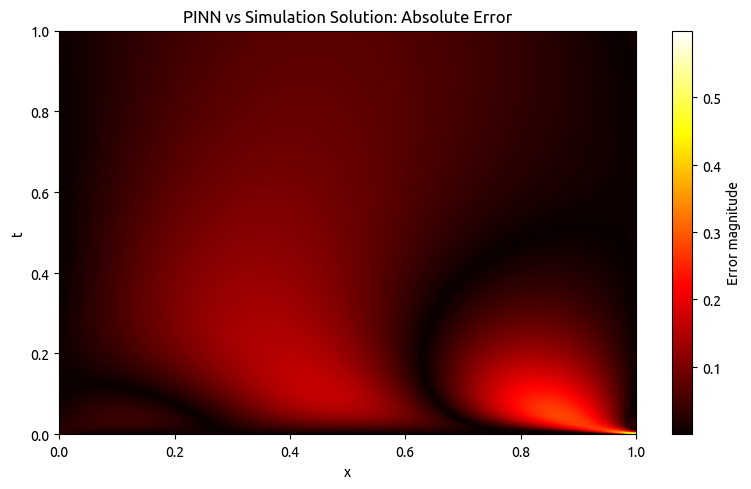

In [ ]:
# Overview of the error between the PINN and simulation solutions

plt = plot_twoD_error('PINN vs Simulation Solution: Absolute Error', model, hist, x, z, ylabel='t')
plt.show()

# Two Dimensional Problems

dirichlet take presidene over neumann at corner points is not implemeted as it doesnt show a difference

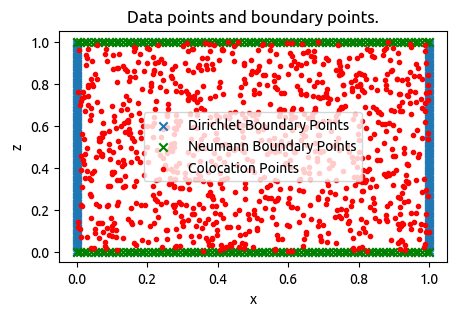

In [10]:
# Create the training and validation data set for the PINN
# and the boundary values for the simulation

# Sample 1000 (x, z) pairs for training
xz_train = gen_rand_2D_data(lower_bound, upper_bound, 1000)

# Generate 900 (x, z) pairs for verification
x_samps = gen_data(lower_bound, upper_bound, 30)
z_samps = gen_data(lower_bound, upper_bound, 30)
grid = tf.meshgrid(x_samps, z_samps)
grid = tf.stack(grid, axis=-1)
xz_test = tf.reshape(grid, [-1, 2])


# Create the Dirichlet/Neumann Boundaries for the x and z domain
x_bc, y_bc = set_boundaries([[0.0], [1.0], [0.0], [1.0]],  # x/z values
                            [[1.0], [0.0], [0.5], [0.5]])  # corresponding 'y' values
                            #  Dirichlet  |   Neumann

# Extend the given boudary values to fit the 2D approach
xz_bc, yz_bc = set_2D_boundaries(x_bc, y_bc, x_train)

# Plot the data points
data = [
    [xz_bc[:len(xz_bc)//2, 0], xz_bc[:len(xz_bc)//2, 1], ('marker', 'x'), 'scatter', ('label', 'Dirichlet Boundary Points')],
    [xz_bc[len(xz_bc)//2:, 0], xz_bc[len(xz_bc)//2:, 1], ('marker', 'x'), 'scatter', ('c', 'g'), ('label', 'Neumann Boundary Points')],
    [xz_train[:, 0], xz_train[:, 1], ('marker', '.'), ('c', 'r'), 'scatter', ('label', 'Colocation Points')]
    ]
plt = simp_plot(data, "Data points and boundary points.", ylabel="z")
plt.show()

In [11]:
# Simulation results for the 2D equation
res = twoD_sim(x_train, y_bc)

# Plot the simulated solution
m = len(res)      # number of z samples
n = len(res[0])   # number of x samples

# Set up the axis
x = np.linspace(lower_bound, upper_bound, n)  # x dimension
z = np.linspace(lower_bound, upper_bound, m)  # z dimension
X, Z = np.meshgrid(x, z)
Y = np.array(res)  # results

plt = int_3D_plot(X, Z, Y, "Plot of the simulated 2D solution", ylabel='z', zlabel='u(x, z)')
plt.show()

In [ ]:
# Train/Test a model for the 2D Problem

# Create a model
model2 = create_model(5, 50)

# Train the model if it is not already trained
try:
    # To force retraining of the model uncomment follwing line
    # raise Exception

    model2 = keras.models.load_model('./data/simp_2D.keras')
except Exception as e:
    error_time = train(model2, xz_train, xz_bc, yz_bc, twoD_loss, lr_schedule, threshold=1e-8, limit=4500)
    model2.save('./data/simp_2D.keras')

    # Create a graph showing the loss vs the epochs
    x, y = zip(*error_time)
    data = list([x, y, 'g-', 'Model Loss'])
    plt = plot_err_vs_epoch(data, 'Development of the Loss over the Epochs', xlabel='Epochs', ylabel='Loss')
    plt.show()


# Calculate the predictions for the verification data
y_pred = model2(xz_test).numpy()

# Create a 3D plot of the preditction of the PINN
X, Z = np.meshgrid(x_samps, z_samps)
Y = y_pred.reshape(30, 30)  # results

plt = int_3D_plot(X, Z, Y, 'Plot of the PINN solution of the 2D Problem.', ylabel='z', zlabel='u(x, z)')
plt.show()

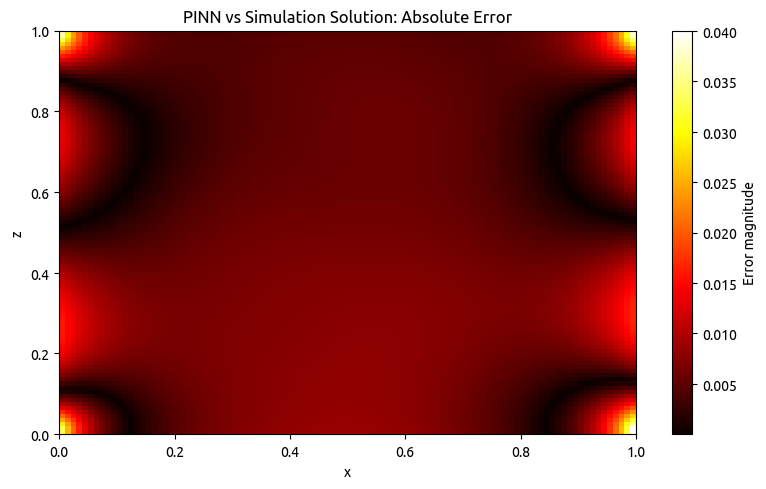

In [13]:
# Overview of the error between the PINN and simulation solutions

plt = plot_twoD_error('PINN vs Simulation Solution: Absolute Error', model2, res, x, z, ylabel='z')
plt.show()

# Complete Problem

In [4]:
# Import the deepsde package
import deepxde as dde

# FYI: dde automatically searches for the most fitting backend that is available,
# but can also be manually set. However newer backends can be a bit complicated 
# to set up, as they require the installation of additional packages, often
# easily conflicting in the installed package versions.
# Here, for tensorflow, the most basic compatability is used, which should always
# work although it does not provide the most modern features. This version of the
# backend also breaks all other tensorflow based functions in the notebooks, as 
# this requieres tf 1 and tf 2 is used otherwise.

# EXECUTING THE PREVIOUS CELLS AFTER THIS ONE WILL LEAD TO ERRORS!

Using backend: tensorflow.compat.v1
Other supported backends: tensorflow, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Instructions for updating:
non-resource variables are not supported in the long term


In [5]:
# Define the PDE and the domain of the problem

# Define the pde as a function of the input value x and
# the predicted value of the model y
def heat_equation(x, y):
    y_xx = dde.grad.hessian(y, x, i=0, j=0)
    y_t = dde.grad.jacobian(y, x, i=0, j=1)
    alpha = 0.1
    return y_t - alpha * y_xx

# Define the dimensions of the time and spatial domain
spat_domain = dde.geometry.Interval(lower_bound, upper_bound)
time_domain = dde.geometry.TimeDomain(lower_bound, upper_bound)
# Define the multi-dimensional space from which to draw the data
xt_geometry = dde.geometry.GeometryXTime(spat_domain, time_domain)
# FYI: This geometry object could also be changed to many different support forms.
# Eg: intervals, rectangles, polygons, or even custom constructed geometry

In [6]:
# Enforce the boundary/initial conditions

# Set the Dirichlet boundary conditions in the x domain
x_bc = dde.icbc.DirichletBC(
    xt_geometry,                # specifies the computational domain on which the bc/s is/are defined
    lambda bp: 1 - bp[:, 0:1],  # takes a set of boundary (x,t)-points and computes the y_bc
    lambda bp, on_boundary:     # the boundary indicator function defines which points count as boundary
        on_boundary and (
            dde.utils.isclose(bp[0], lower_bound) or dde.utils.isclose(bp[0], upper_bound)
        )
)
# FYI: The indicator function is boolean and takes 2 arguments:
#    1: a point from the computational domain
#    2: on_boundary flag, that is set true if the point from 1 is on
#       the boundary defined by the geometry.
# In simple xt-domains dde automatically knows to enforce the bcs only on the spatial domain.
# If, however, a multi-dimensional spatial domain is provided, the affected boundary must be
# explicitly specified.

# Set the initial conditon
ic = dde.icbc.IC(
    xt_geometry,                                             # definition of the computational domain
    lambda bp:  0.5 * np.cos(2 * np.pi * bp[:, 0:1]) + 0.5,  # function from above to compute the intial solution
    lambda _, on_initial:                                    # condition function defining the initial time points
        on_initial
)
# FYI: The condition function is boolean and takes 2 arguments:
#    1: a point from the domain
#    2: on_initial flag, that is set to true if the point is given
#       on the lowest (first possible) coordinate of the t-domain.
# As before, for simple xt-problems the initial condition is automatically applied to t.

In [7]:
# Set up the data model for the PINN by collecting the
# conditions, the space and the equation into 1 object.
data = dde.data.TimePDE(
    xt_geometry,      # set the computational domain from which to sample the points
    heat_equation,    # the pde to solve
    [x_bc, ic],       # set of the boundary/initial conditions
    num_domain=2550,  # num of points to sample on the 'inside' of the geometry
    num_boundary=80,  # num of points accross the boundary conditions
    num_initial=160,  # num of points for the initial solution
    num_test=2550     # num of points to evaluate for validation
)
# FYI: TimePDE organizes all the information/sampling needed to solve a time-dependent
# PDE, respecting the different approach in such a case.

Compiling model...
Building feed-forward neural network...
'build' took 0.105943 s

'compile' took 0.544039 s

Training model...

Step      Train loss                        Test loss                         Test metric
0         [1.64e-03, 5.71e-01, 5.54e-01]    [1.69e-03, 5.71e-01, 5.54e-01]    []  
1000      [7.04e-04, 5.77e-03, 4.35e-03]    [3.76e-04, 5.77e-03, 4.35e-03]    []  
2000      [3.00e-03, 2.98e-03, 1.96e-03]    [2.12e-03, 2.98e-03, 1.96e-03]    []  
3000      [4.00e-04, 1.21e-03, 1.11e-03]    [2.39e-04, 1.21e-03, 1.11e-03]    []  
4000      [2.25e-04, 7.72e-04, 7.05e-04]    [1.76e-04, 7.72e-04, 7.05e-04]    []  
4500      [9.93e-04, 7.65e-04, 5.32e-04]    [5.09e-04, 7.65e-04, 5.32e-04]    []  

Best model at step 4000:
  train loss: 1.70e-03
  test loss: 1.65e-03
  test metric: []

'train' took 101.070354 s



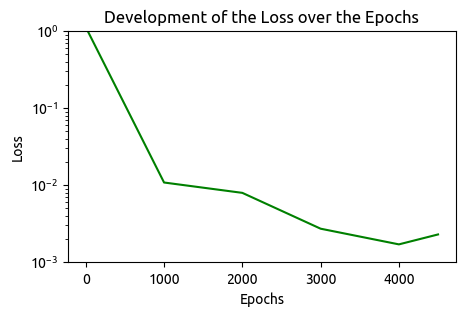

In [8]:
# Train/Test a model for the full Problem

# Create and compile a model
net = dde.nn.FNN([2] + [50] * 5 + [1],  # each [] represents the #neurons per layer (including the "input neurons")
                "tanh",                 # activation function
                "Glorot uniform"        # initialization for the weights
            )
model3 = dde.Model(data, net)            # create a model from the net and the data
model3.compile("adam", lr=1e-3)

# Train the model if it is not already trained
try:
    # To force retraining of the model uncomment follwing line
    # raise Exception

    model3 = model3.restore('./data/full_2D.ckpt-4500')
except Exception as e:
    losshistory, train_state = model3.train(iterations=4500)  # iterations = max number of epochs
    # model3.save('./data/full_2D.ckpt-4500')

    # Create a graph showing the loss vs the epochs
    x = np.array(losshistory.steps)
    y = np.array([np.sum(loss) for loss in losshistory.loss_train])
    data = list([x, y, 'g-', 'Model Loss'])
    plt = plot_err_vs_epoch(data, 'Development of the Loss over the Epochs', xlabel='Epochs', ylabel='Loss')
    plt.show()


# Create a test data set for the visual comparison
xt_test = xt_geometry.uniform_points(10000, True)
# Calculate the predictions for the verification data
y_pred = model3.predict(xt_test)

# Create a 3D plot of the preditction of the PINN
x_samps = np.linspace(lower_bound, upper_bound, 100)
z_samps = np.linspace(lower_bound, upper_bound, 100)
X, Z = np.meshgrid(x_samps, z_samps)
Y = y_pred.reshape(100, 100)  # results

plt = int_3D_plot(X, Z, Y, 'Plot of the PINN solution of the 2D Problem.', ylabel='t', zlabel='u(x, t)')
plt.show()